In [1]:
import os
import shutil
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision.models import resnet101, ResNet101_Weights

In [2]:
class EmotionDataset:
    def __init__(self, root_dir='/kaggle/input/emotion-recognition-dataset/dataset'):
        self.root_dir = root_dir
        self.balanced_dir = '/kaggle/working/balanced_dataset'
        self.train_dir = 'train'
        self.test_dir = 'test'
        self.emotions = ["Ahegao", "Angry", "Happy", "Neutral", "Sad", "Surprise"]
        
    def balance_dataset(self):
        # Find minimum class size
        min_size = float('inf')
        for emotion in self.emotions:
            path = os.path.join(self.root_dir, emotion)
            size = len(os.listdir(path))
            min_size = min(min_size, size)
        
        # Create balanced dataset directory
        os.makedirs(self.balanced_dir, exist_ok=True)
        
        # Balance each class
        for emotion in self.emotions:
            src_path = os.path.join(self.root_dir, emotion)
            dst_path = os.path.join(self.balanced_dir, emotion)
            os.makedirs(dst_path, exist_ok=True)
            
            # Get all files and randomly select min_size
            files = os.listdir(src_path)
            selected_files = np.random.choice(files, min_size, replace=False)
            
            # Copy selected files
            for file in selected_files:
                src_file = os.path.join(src_path, file)
                dst_file = os.path.join(dst_path, file)
                shutil.copy2(src_file, dst_file)
                
    def split_dataset(self):
        # Create train and test directories
        os.makedirs(self.train_dir, exist_ok=True)
        os.makedirs(self.test_dir, exist_ok=True)
        
        for emotion in self.emotions:
            # Create emotion directories in train and test
            os.makedirs(os.path.join(self.train_dir, emotion), exist_ok=True)
            os.makedirs(os.path.join(self.test_dir, emotion), exist_ok=True)
            
            # Get all files in the balanced emotion directory
            emotion_path = os.path.join(self.balanced_dir, emotion)
            files = os.listdir(emotion_path)
            
            # Split files into train and test
            train_files, test_files = train_test_split(files, test_size=0.1, random_state=42)
            
            # Copy files to respective directories
            for file in train_files:
                src = os.path.join(emotion_path, file)
                dst = os.path.join(self.train_dir, emotion, file)
                shutil.copy2(src, dst)
                
            for file in test_files:
                src = os.path.join(emotion_path, file)
                dst = os.path.join(self.test_dir, emotion, file)
                shutil.copy2(src, dst)


In [4]:
class EmotionImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        
        self.images = []
        self.labels = []
        
        for cls in self.classes:
            class_path = os.path.join(root_dir, cls)
            for img_name in os.listdir(class_path):
                self.images.append(os.path.join(class_path, img_name))
                self.labels.append(self.class_to_idx[cls])
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label


In [5]:
def train_model():
    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    transform = transforms.Compose([
    transforms.RandomResizedCrop((224, 224), scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
    # Create datasets
    train_dataset = EmotionImageDataset('train', transform=transform)
    train_size = int(0.9 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])
    test_dataset = EmotionImageDataset('test', transform=transform)
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
    
    # Load ResNet model
    model = models.resnet101(weights=ResNet101_Weights.DEFAULT)
    
    # Modify the classifier for 6 emotion classes
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 6)
    model = model.to(device)
    
    # Loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5)
    
    # Training setup
    num_epochs = 20
    train_losses = []
    val_losses = []
    best_val_acc = 0
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
        
        train_loss = train_loss / len(train_loader)
        train_acc = 100. * train_correct / train_total
        train_losses.append(train_loss)
        
        # Validation
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        
        val_loss = val_loss / len(val_loader)
        val_acc = 100. * val_correct / val_total
        val_losses.append(val_loss)
        
        scheduler.step(val_loss)
        
        print(f'Epoch [{epoch+1}/{num_epochs}]')
        print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pth')
    
    # Plot training curves
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.savefig('training_curves.png')
    plt.close()
    
    # Test evaluation
    model.load_state_dict(torch.load('best_model.pth', weights_only=True))
    model.eval()
    test_correct = 0
    test_total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()
    
    test_acc = 100. * test_correct / test_total
    print(f'\nBest Validation Accuracy: {best_val_acc:.2f}%')
    print(f'\nTest Accuracy: {test_acc:.2f}%')


In [6]:
import torch
import torch.nn as nn
import torchvision.models as models

class EmotionRecognitionModel(nn.Module):
    def __init__(self, num_classes):
        super(EmotionRecognitionModel, self).__init__()

        # Load the ResNet-101 model with pre-trained weights
        self.resnet101 = models.resnet101(weights=models.ResNet101_Weights.DEFAULT)

        # Freeze the first few layers (optional, adjust as needed)
        for param in list(self.resnet101.parameters())[:5]:
            param.requires_grad = False

        # Replace the ResNet-101 fully connected layer with a custom classifier
        self.resnet101.fc = nn.Sequential(
            nn.BatchNorm1d(2048),
            nn.Dropout(0.5),
            nn.Linear(2048, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.resnet101(x)
        return torch.softmax(x, dim=1)

In [7]:
if __name__ == "__main__":
    # Initialize and process dataset
    dataset = EmotionDataset()
    dataset.balance_dataset()
    dataset.split_dataset()
    train_model()


Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth
100%|██████████| 171M/171M [00:00<00:00, 205MB/s] 
Epoch 1/20: 100%|██████████| 92/92 [02:06<00:00,  1.38s/it]


Epoch [1/20]
Train Loss: 0.9004, Train Acc: 65.83%
Val Loss: 0.7730, Val Acc: 73.27%


Epoch 2/20: 100%|██████████| 92/92 [02:05<00:00,  1.36s/it]


Epoch [2/20]
Train Loss: 0.5909, Train Acc: 78.03%
Val Loss: 0.7602, Val Acc: 70.05%


Epoch 3/20: 100%|██████████| 92/92 [02:05<00:00,  1.37s/it]


...

Epoch [18/20]
Train Loss: 0.1946, Train Acc: 92.94%
Val Loss: 0.5664, Val Acc: 81.87%


Epoch 19/20: 100%|██████████| 92/92 [02:04<00:00,  1.36s/it]


Epoch [19/20]
Train Loss: 0.1340, Train Acc: 94.98%
Val Loss: 0.3944, Val Acc: 86.48%


Epoch 20/20: 100%|██████████| 92/92 [02:04<00:00,  1.35s/it]


Epoch [20/20]
Train Loss: 0.0867, Train Acc: 97.20%
Val Loss: 0.4075, Val Acc: 85.56%

Best Validation Accuracy: 86.48%

Test Accuracy: 86.36%


In [10]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.models import ResNet101_Weights

def resume_training():
    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Data transforms
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    # Load datasets
    train_dataset = EmotionImageDataset('train', transform=transform)

    train_size = int(0.9 * len(train_dataset))
    val_size = len(train_dataset) - train_size

    train_dataset, val_dataset = torch.utils.data.random_split(
        train_dataset,
        [train_size, val_size]
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=64,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=64,
        shuffle=False
    )

    # Load model
    model = models.resnet101(weights=ResNet101_Weights.DEFAULT)

    model.fc = nn.Linear(
        model.fc.in_features,
        6
    )

    model = model.to(device)

    # Load saved weights
    model.load_state_dict(
        torch.load(
            "best_model.pth",
            map_location=device
        )
    )

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=5
    )

    best_val_acc = 0

    num_epochs = 10

    for epoch in range(num_epochs):

        model.train()

        train_loss = 0

        for images, labels in tqdm(train_loader):

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            train_loss += loss.item()

        # Validation

        model.eval()

        val_correct = 0
        val_total = 0
        val_loss = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = outputs.max(1)

                val_total += labels.size(0)

                val_correct += (predicted == labels).sum().item()

        val_acc = 100 * val_correct / val_total

        scheduler.step(val_loss)

        print(f"Epoch {epoch+1}")
        print(f"Validation Accuracy: {val_acc:.2f}%")

        if val_acc > best_val_acc:

            best_val_acc = val_acc

            torch.save(
                model.state_dict(),
                "best_model.pth"
            )

            print("Best model saved.")

    return model


if __name__ == "__main__":

    # Resume training
    model = resume_training()

    model.eval()

    print("Training completed.")

    # --------------------------
    # Export to ONNX
    # --------------------------

    dummy_input = torch.randn(
        1,
        3,
        224,
        224
    )

    torch.onnx.export(
        model,
        dummy_input,
        "emotion_model.onnx",
        export_params=True,
        opset_version=13,
        do_constant_folding=True,
        input_names=["input"],
        output_names=["output"],
        dynamic_axes={
            "input": {0: "batch_size"},
            "output": {0: "batch_size"}
        }
    )

    print("ONNX model exported successfully.")

<ipython-input-10-31ea85be8ec9>:57: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(
100%|██████████| 92/92 [01:30<00:00,  1.01it/s]


Epoch 1
Validation Accuracy: 95.55%
Best model saved.


100%|██████████| 92/92 [01:31<00:00,  1.01it/s]


Epoch 2
Validation Accuracy: 93.55%


100%|██████████| 92/92 [01:30<00:00,  1.02it/s]


...

100%|██████████| 92/92 [01:30<00:00,  1.02it/s]


Epoch 9
Validation Accuracy: 94.47%


100%|██████████| 92/92 [01:30<00:00,  1.01it/s]


Epoch 10
Validation Accuracy: 95.85%
Best model saved.
Training completed.


RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor

In [11]:
# --------------------------
# Export to ONNX
# --------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()

dummy_input = torch.randn(
    1,
    3,
    224,
    224,
    device=device
)

torch.onnx.export(
    model,
    dummy_input,
    "emotion_model.onnx",
    export_params=True,
    opset_version=13,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "output": {0: "batch_size"}
    }
)

print("✅ ONNX model exported successfully!")

✅ ONNX model exported successfully!


In [12]:
import onnx

model = onnx.load("emotion_model.onnx")
onnx.checker.check_model(model)

print("ONNX model is valid.")

ONNX model is valid.


In [14]:
import torch
from torchvision import transforms
from torch.utils.data import DataLoader
import torchvision.models as models
import torch.nn as nn
from torchvision.models import ResNet101_Weights

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Test transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load test dataset
test_dataset = EmotionImageDataset(
    "test",
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

# Create model
model = models.resnet101(weights=None)

model.fc = nn.Linear(
    model.fc.in_features,
    6
)

# Load trained weights
model.load_state_dict(
    torch.load("best_model.pth", map_location=device)
)

model = model.to(device)
model.eval()

# Test
test_correct = 0
test_total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_accuracy = 100 * test_correct / test_total

print(f"Test Accuracy: {test_accuracy:.2f}%")

<ipython-input-14-641ddc308ff8>:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("best_model.pth", map_location=device)


Test Accuracy: 86.91%


In [15]:
from sklearn.metrics import classification_report, confusion_matrix

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predicted.cpu().numpy())

print(classification_report(
    all_labels,
    all_predictions,
    target_names=test_dataset.classes
))

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_predictions))

              precision    recall  f1-score   support

      Ahegao       0.98      1.00      0.99       121
       Angry       0.89      0.90      0.90       121
       Happy       0.92      0.91      0.92       121
     Neutral       0.73      0.85      0.79       121
         Sad       0.82      0.67      0.74       121
    Surprise       0.88      0.88      0.88       121

    accuracy                           0.87       726
   macro avg       0.87      0.87      0.87       726
weighted avg       0.87      0.87      0.87       726

Confusion Matrix:
[[121   0   0   0   0   0]
 [  0 109   0   3   5   4]
 [  0   3 110   4   0   4]
 [  2   0   1 103  12   3]
 [  0   5   5  27  81   3]
 [  1   5   3   4   1 107]]


In [16]:
from IPython.display import FileLink

FileLink("emotion_model.onnx")

/kaggle/working/emotion_model.onnx

## Testing

In [17]:
!pip install -q onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 72.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 4.8 MB/s eta 0:00:00


In [18]:
import onnxruntime as ort
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

In [19]:
session = ort.InferenceSession("emotion_model.onnx")

input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

print("Input:", input_name)
print("Output:", output_name)

Input: input
Output: output


In [20]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [21]:
labels = [
    "Ahegao",
    "Angry",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

In [24]:
import numpy as np

def softmax(x):
    e = np.exp(x - np.max(x))
    return e / e.sum()

def predict_image(image_path):

    image = Image.open(image_path).convert("RGB")

    img = transform(image)
    img = img.unsqueeze(0)
    img = img.numpy().astype(np.float32)

    outputs = session.run(
        [output_name],
        {input_name: img}
    )[0]

    probs = softmax(outputs[0])

    prediction = np.argmax(probs)

    confidence = probs[prediction] * 100

    plt.imshow(image)
    plt.axis("off")
    plt.title(f"{labels[prediction]} ({confidence:.2f}%)")
    plt.show()

    return labels[prediction], confidence

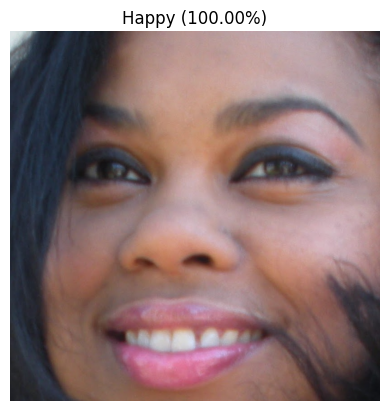

('Happy', 99.99985694885254)

In [25]:
predict_image("/kaggle/working/balanced_dataset/Happy/00a1e228b74ad9663ec8cb9aad62d0e1ed89d29f45c1a55efd73e0fa.JPG")

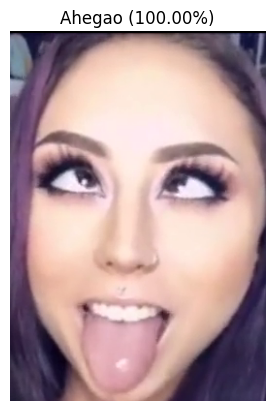

('Ahegao', 100.0)

In [27]:

predict_image("/kaggle/working/balanced_dataset/Ahegao/cropped_emotions.16023~ahegao.png")
